In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.ensemble import RandomForestClassifier, RandomForestClassifier
import matplotlib.pyplot as plt
!pip install joblib
import joblib

## Data Loading

In [26]:
path=Path('../../data/insider_threat_clean_dataset.csv')
df_raw = pd.read_csv(path)

## Preprocessing

In [27]:
df_raw=df_raw.drop_duplicates()
df_raw = df_raw.dropna()

## Feature Engineering

i dropped the following features from the dataset: `employee_campus`, `has_medical_history`, `employee_origin_country`, `has_foreign_citizenship`, and `is_contractor`. 

removed these features for ethics prevention. fields like medical history, nationality, and foreign citizenship do not indicate malicious behaviour and could introduce bias and discrimination in the model. I dropped the `employee_campus` feature because physical location doesnt really help in this case as someone infiltrating a system isnt dependent on their campus and if we know which campuses were accessed and how often they were accessed would be more insightful for model training.

In [28]:
df_raw=df_raw.drop(columns=[
    'employee_campus',
    'has_medical_history',
    'employee_origin_country',
    'has_foreign_citizenship','is_contractor'])
df_encoded = pd.get_dummies(df_raw,columns=[
    'employee_department',
    'employee_position'],
    prefix='categ')

I encoded the remaining features because they directly map to the behavioural indicators of insider threats required for the model

**Login Time Patterns & Abnormal Access Frequency**

The features I selected to track this include `entry_during_weekend`, `late_exit_flag`, `num_entries` and `num_unique_campus`. Malicious insiders often attempt to access systems outside of normal working hours to avoid detection.

**Data Transfer Behaviour & File Access Activity**

To monitor this I selected `total_files_burned`, `burned_from_other`, `total_printed_pages` and `num_printed_pages_off_hours`. Since data being extracted from the organisation being the  primary goal of an insider threat copying files and pages shows direct file access and data transfer activities.

**Privilege usage**

Baseline field indicators include `employee_classification`, `employee_seniority_years`, `employee_department` and `employee_position`.

**Additional Contextual Risk Indicators**

Lastly `has_criminal_record`, `is_abroad`, `trip_day_number`, and `hostility_country_level`. These field help my model weigh external risk factors.

In [29]:
df_raw.columns.to_frame(name="features/fields",index=False)

,features/fields
0,employee_department
1,employee_position
2,employee_seniority_years
3,employee_classification
4,has_criminal_record
5,total_printed_pages
6,num_printed_pages_off_hours
7,total_files_burned
8,burned_from_other
9,is_abroad


In [30]:
feature_trn,feature_tst,label_trn,label_tst = sk.model_selection.train_test_split(
    df_encoded.drop(columns=['is_malicious']),
    df_encoded.is_malicious,
    train_size=0.75,
    random_state=113)

***I selected the Random Forest Classifier***

- Since the dataset is tablular with unique categorise and majority boolean and numerical values. Random Forest is made up of decision trees and this made it the prime candidate in this aspect for its tabular nature and how its known to out perform most models with this type of structured data.
- Random Forest does not require strict normalization. This sped up my preprocessing and ensured that the raw meaning of the data the exact count of off-hours logins was preserved during training.

In [31]:
forest = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced',
    random_state=113
    ) #created a random forest object that would be used for trianing with pre paramters like the seed value of 113 aswell as the weight class and the total depth of the tree

forest.fit(feature_trn,label_trn) #the training sequence initiated
forest_pred = forest.predict(feature_tst) #the predicted values are generated and they are evaluated after they are calculated

In [32]:
print("\n*** Classification Report ***")
print(sk.metrics.classification_report(label_tst, forest_pred))


*** Classification Report ***
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     28046
           1       0.57      0.78      0.66      1608

    accuracy                           0.96     29654
   macro avg       0.78      0.88      0.82     29654
weighted avg       0.96      0.96      0.96     29654



In [33]:
print("*** Confusion Matrix ***")
print(sk.metrics.confusion_matrix(label_tst, forest_pred))

*** Confusion Matrix ***
[[27099   947]
 [  347  1261]]


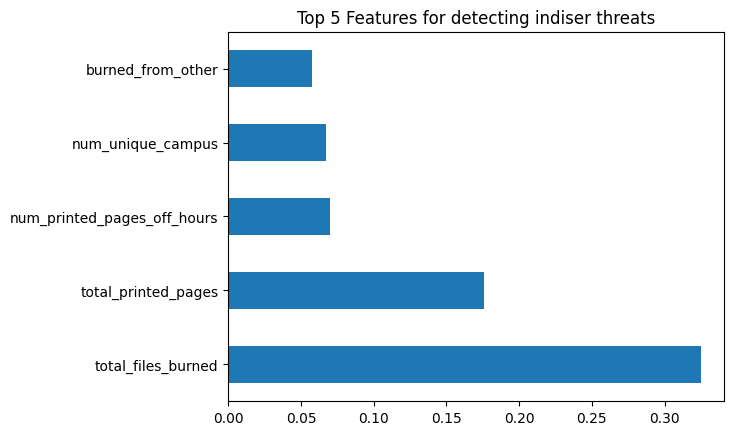

In [34]:
scores = pd.Series(forest.feature_importances_,index=df_encoded.drop(columns=['is_malicious']).columns)
scores.nlargest(5).plot(kind='barh')
plt.title("Top 5 Features for detecting indiser threats")
plt.show()

In [35]:
df_raw.is_malicious.explode().value_counts().to_frame()

,is_malicious
0,112228
1,6386


In [36]:
lst=list(df_raw.is_malicious.explode().value_counts())
(lst[1]/lst[0])*100

5.690202088605338

In [ ]:
path=Path('..\models')
model_file_path = path/'RForestModel.pkl'
joblib.dump(forest, model_file_path)